# Classical ML Results — Combined NASA PCoE + CALCE CS2

Loads the **canonical** benchmark outputs (`experiments/classical_results_all.yaml`,
`experiments/dl_results_all.yaml`, `experiments/fold_indices_all.json`) and the persisted
per-fold models. Training itself lives in `src/models/train_classical.py` /
`src/models/train_dl.py`, which implement the leakage-safe protocol:

- feature selection fitted per fold on training cells only;
- hyperparameter tuning on an inner cell split (test cell untouched);
- final refit on the full training fold; single-sample inference benchmarks.

This notebook visualises and analyses those results — it does NOT retrain.


In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / "config" / "default.yaml").exists():
        PROJECT_ROOT = _p
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root (config/default.yaml)")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import yaml

sns.set_theme(style="whitegrid", context="notebook")

with open("experiments/classical_results_all.yaml") as f:
    classical_results = yaml.safe_load(f)
with open("experiments/dl_results_all.yaml") as f:
    dl_results = yaml.safe_load(f)
with open("experiments/fold_indices_all.json") as f:
    folds_payload = json.load(f)

meta = classical_results.get("_meta", {})
print("Protocol:", meta.get("protocol"))
print("Dataset:", meta.get("dataset"), "| folds:", meta.get("n_folds"))


Project root: /Users/malakmekyassi/Documents/GitHub/soh_estimation


Protocol: cell-based LOOCV; per-fold feature selection; inner-cell-split hyperparameter tuning; refit on full training fold
Dataset: all | folds: 8


## 1. Benchmark Setup

Fold structure recorded during training (`experiments/fold_indices_all.json`).


In [2]:
folds = folds_payload["folds"]
for f in folds:
    print(f"Fold {f['fold']}: test={f['test_cell']}, train_rows={len(f['train_indices'])}, test_rows={len(f['test_indices'])}")


Fold 0: test=B0005, train_rows=3027, test_rows=168
Fold 1: test=B0006, train_rows=3027, test_rows=168
Fold 2: test=B0007, train_rows=3027, test_rows=168
Fold 3: test=B0018, train_rows=3063, test_rows=132
Fold 4: test=CS2_33, train_rows=2599, test_rows=596
Fold 5: test=CS2_34, train_rows=2573, test_rows=622
Fold 6: test=CS2_35, train_rows=2542, test_rows=653
Fold 7: test=CS2_36, train_rows=2507, test_rows=688


## 2. Aggregated Results (canonical YAMLs)


In [3]:
def to_frame(results, kind):
    rows = []
    for name, m in results.items():
        if not isinstance(m, dict) or "rmse_mean" not in m:
            continue
        rows.append({
            "Model": name.upper(), "Kind": kind,
            "RMSE": m["rmse_mean"], "RMSE_std": m["rmse_std"],
            "MAE": m["mae_mean"], "MaxAE": m["maxae_mean"],
            "R2": m["r2_mean"], "R2_std": m["r2_std"],
            "Inference_ms": m.get("inference_time_ms_mean", np.nan),
        })
    return pd.DataFrame(rows).sort_values("RMSE")

summary_df = pd.concat([to_frame(classical_results, "classical"),
                        to_frame(dl_results, "dl")]).reset_index(drop=True)
print(summary_df.to_string(index=False))
summary_df


      Model      Kind     RMSE  RMSE_std      MAE    MaxAE        R2   R2_std  Inference_ms
        GPR classical 0.025230  0.012317 0.019945 0.084451  0.894105 0.086102      2.254808
         RF classical 0.025440  0.017368 0.019703 0.073498  0.894266 0.098826     25.729995
        SVR classical 0.034212  0.017982 0.026085 0.127398  0.791170 0.223001      0.082635
      NAIVE classical 0.103416  0.038249 0.091056 0.187113 -0.422329 0.478025      0.000667
TRANSFORMER        dl 0.034401  0.012344 0.028096 0.111847  0.785776 0.143464      2.077780
       LSTM        dl 0.040961  0.024005 0.035314 0.120016  0.713130 0.246463      0.769103
        CNN        dl 0.048935  0.026613 0.040873 0.147138  0.457583 0.639672      0.624127


,Model,Kind,RMSE,RMSE_std,MAE,MaxAE,R2,R2_std,Inference_ms
0,GPR,classical,0.025230,0.012317,0.019945,0.084451,0.894105,0.086102,2.254808
1,RF,classical,0.025440,0.017368,0.019703,0.073498,0.894266,0.098826,25.729995
2,SVR,classical,0.034212,0.017982,0.026085,0.127398,0.791170,0.223001,0.082635
3,NAIVE,classical,0.103416,0.038249,0.091056,0.187113,-0.422329,0.478025,0.000667
4,TRANSFORMER,dl,0.034401,0.012344,0.028096,0.111847,0.785776,0.143464,2.077780
5,LSTM,dl,0.040961,0.024005,0.035314,0.120016,0.713130,0.246463,0.769103
6,CNN,dl,0.048935,0.026613,0.040873,0.147138,0.457583,0.639672,0.624127


## 3. RMSE / R² Comparison


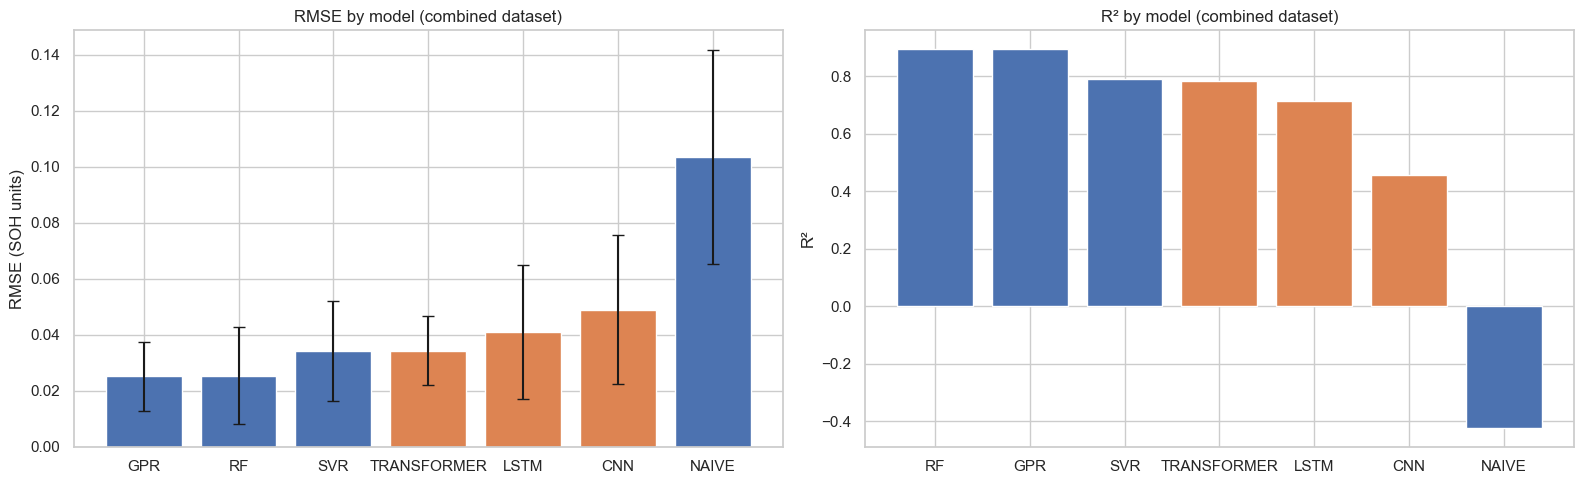

Best overall: GPR (RMSE=0.0252, R2=0.894)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_df = summary_df.sort_values("RMSE")
axes[0].bar(plot_df["Model"], plot_df["RMSE"],
            yerr=plot_df["RMSE_std"], capsize=4,
            color=["#4c72b0" if k == "classical" else "#dd8452" for k in plot_df["Kind"]])
axes[0].set_title("RMSE by model (combined dataset)")
axes[0].set_ylabel("RMSE (SOH units)")

plot_r = summary_df.sort_values("R2", ascending=False)
axes[1].bar(plot_r["Model"], plot_r["R2"],
            color=["#4c72b0" if k == "classical" else "#dd8452" for k in plot_r["Kind"]])
axes[1].set_title("R² by model (combined dataset)")
axes[1].set_ylabel("R²")
plt.tight_layout()
plt.show()

best_row = summary_df.sort_values("RMSE").iloc[0]
print(f"Best overall: {best_row['Model']} (RMSE={best_row['RMSE']:.4f}, R2={best_row['R2']:.3f})")


## 4. Per-fold RMSE (from canonical results)


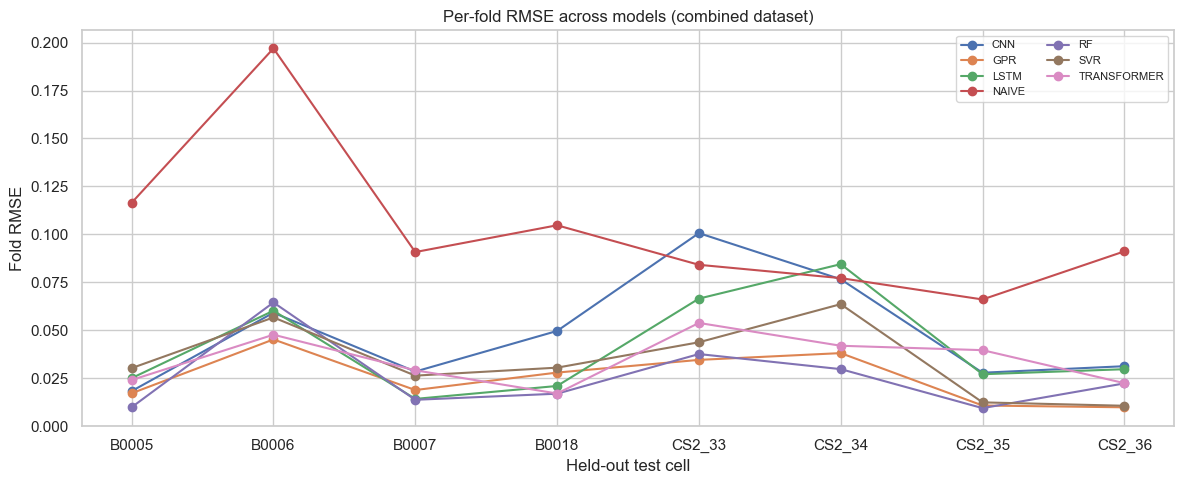

Mean RMSE per fold (all models):
Fold
1    0.075737
4    0.060097
5    0.058755
3    0.038189
0    0.034382
2    0.031579
7    0.030978
6    0.027536


In [5]:
fold_rows = []
for name, m in {**classical_results, **dl_results}.items():
    if not isinstance(m, dict) or "per_fold_rmse" not in m:
        continue
    for i, rmse in enumerate(m["per_fold_rmse"]):
        fold_rows.append({"Model": name.upper(), "Fold": i, "RMSE": rmse})

fold_df = pd.DataFrame(fold_rows)
fig, ax = plt.subplots(figsize=(12, 5))
for name, grp in fold_df.groupby("Model"):
    ax.plot(grp["Fold"], grp["RMSE"], marker="o", label=name)
ax.set_xticks(sorted(fold_df["Fold"].unique()))
ax.set_xticklabels([f["test_cell"] for f in sorted(folds, key=lambda x: x["fold"])])
ax.set_xlabel("Held-out test cell")
ax.set_ylabel("Fold RMSE")
ax.set_title("Per-fold RMSE across models (combined dataset)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

hardest = fold_df.groupby("Fold")["RMSE"].mean().sort_values(ascending=False)
print("Mean RMSE per fold (all models):")
print(hardest.to_string())


## 5. Prediction vs. True SOH — SVR and RF (persisted fold models)


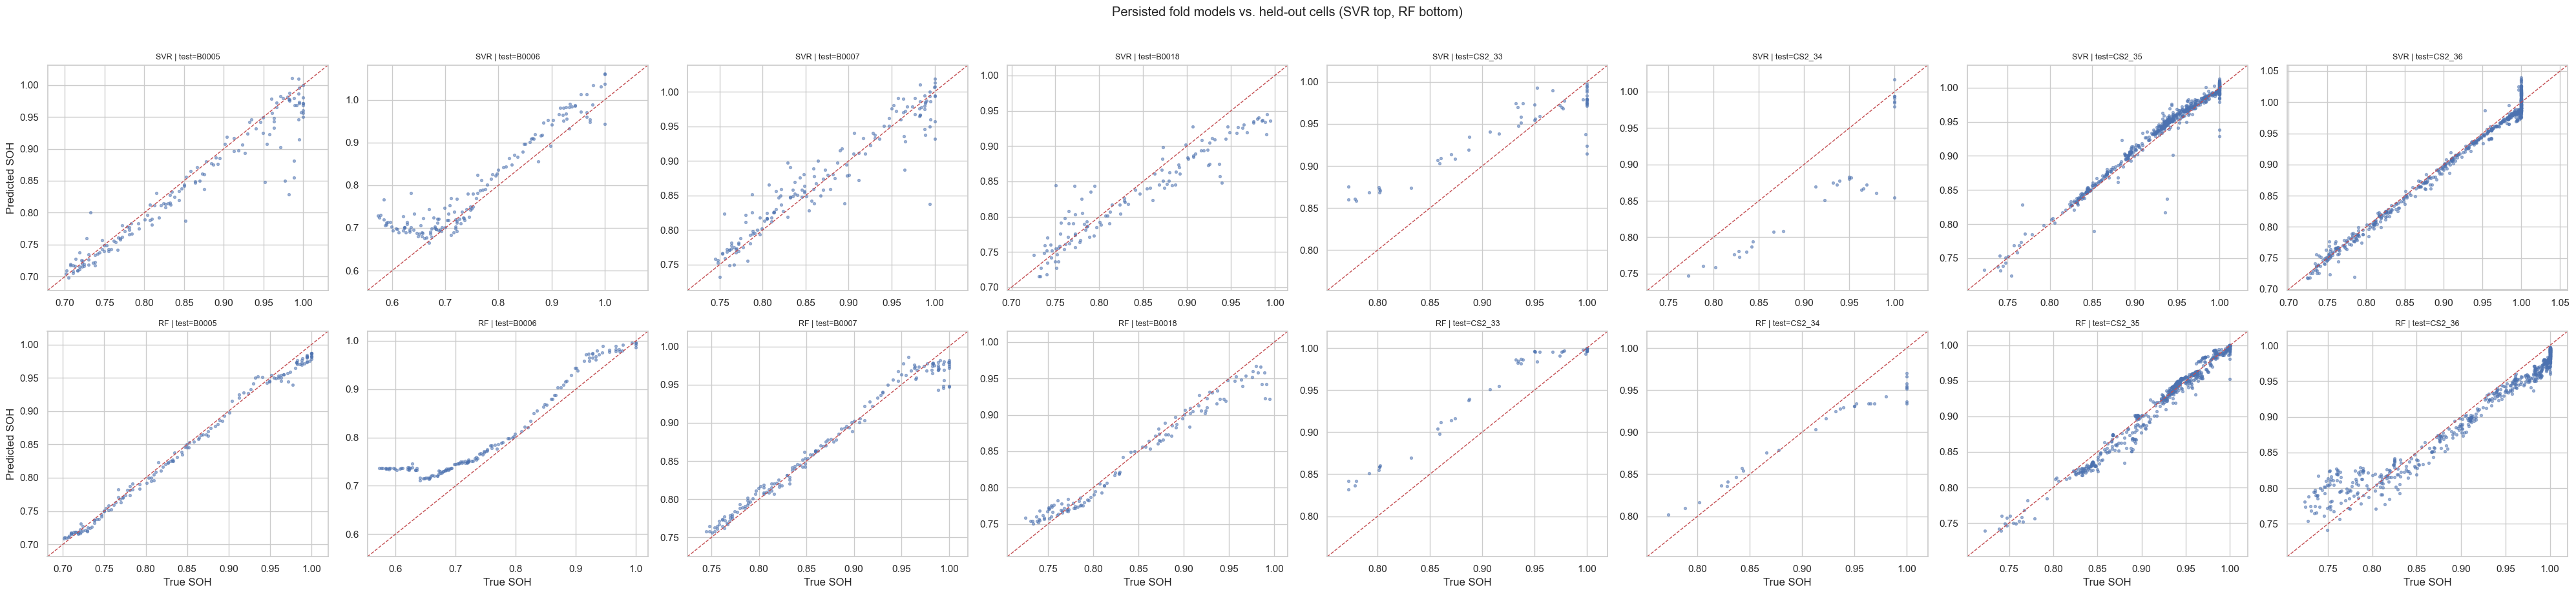

In [6]:
feature_df = pd.read_parquet("data/features/feature_matrix_all.parquet")

fig, axes = plt.subplots(2, 8, figsize=(40, 9))

for row, model_name in enumerate(["svr", "rf"]):
    for col, fold in enumerate(sorted(folds, key=lambda f: f["fold"])):
        ax = axes[row, col]
        art = joblib.load(f"experiments/models/all/{model_name}_fold{fold['fold']}.joblib")
        model, feat_cols = art["model"], art["feature_cols"]

        tr = feature_df.loc[fold["train_indices"]].dropna(subset=feat_cols + ["soh"])
        te = feature_df.loc[fold["test_indices"]].dropna(subset=feat_cols + ["soh"])

        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler().fit(tr[feat_cols].values)
        X_te = scaler.transform(te[feat_cols].values)

        y_true = te["soh"].values
        y_pred = model.predict(X_te)
        lims = [min(y_true.min(), y_pred.min()) - 0.02, max(y_true.max(), y_pred.max()) + 0.02]
        ax.scatter(y_true, y_pred, s=8, alpha=0.5)
        ax.plot(lims, lims, "r--", lw=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(f"{model_name.upper()} | test={fold['test_cell']}", fontsize=9)
        if col == 0:
            ax.set_ylabel("Predicted SOH")
        if row == 1:
            ax.set_xlabel("True SOH")
plt.suptitle("Persisted fold models vs. held-out cells (SVR top, RF bottom)", y=1.02)
plt.tight_layout()
plt.show()


## Summary

Findings below are computed from the canonical YAMLs loaded above (no hand-copied numbers).

**Methodology:** all reported metrics come from the leakage-safe protocol described at the top.
Feature selection and hyperparameter tuning never touch the held-out cell; inference times are
measured single-sample `predict()` latencies of the persisted fold models.
